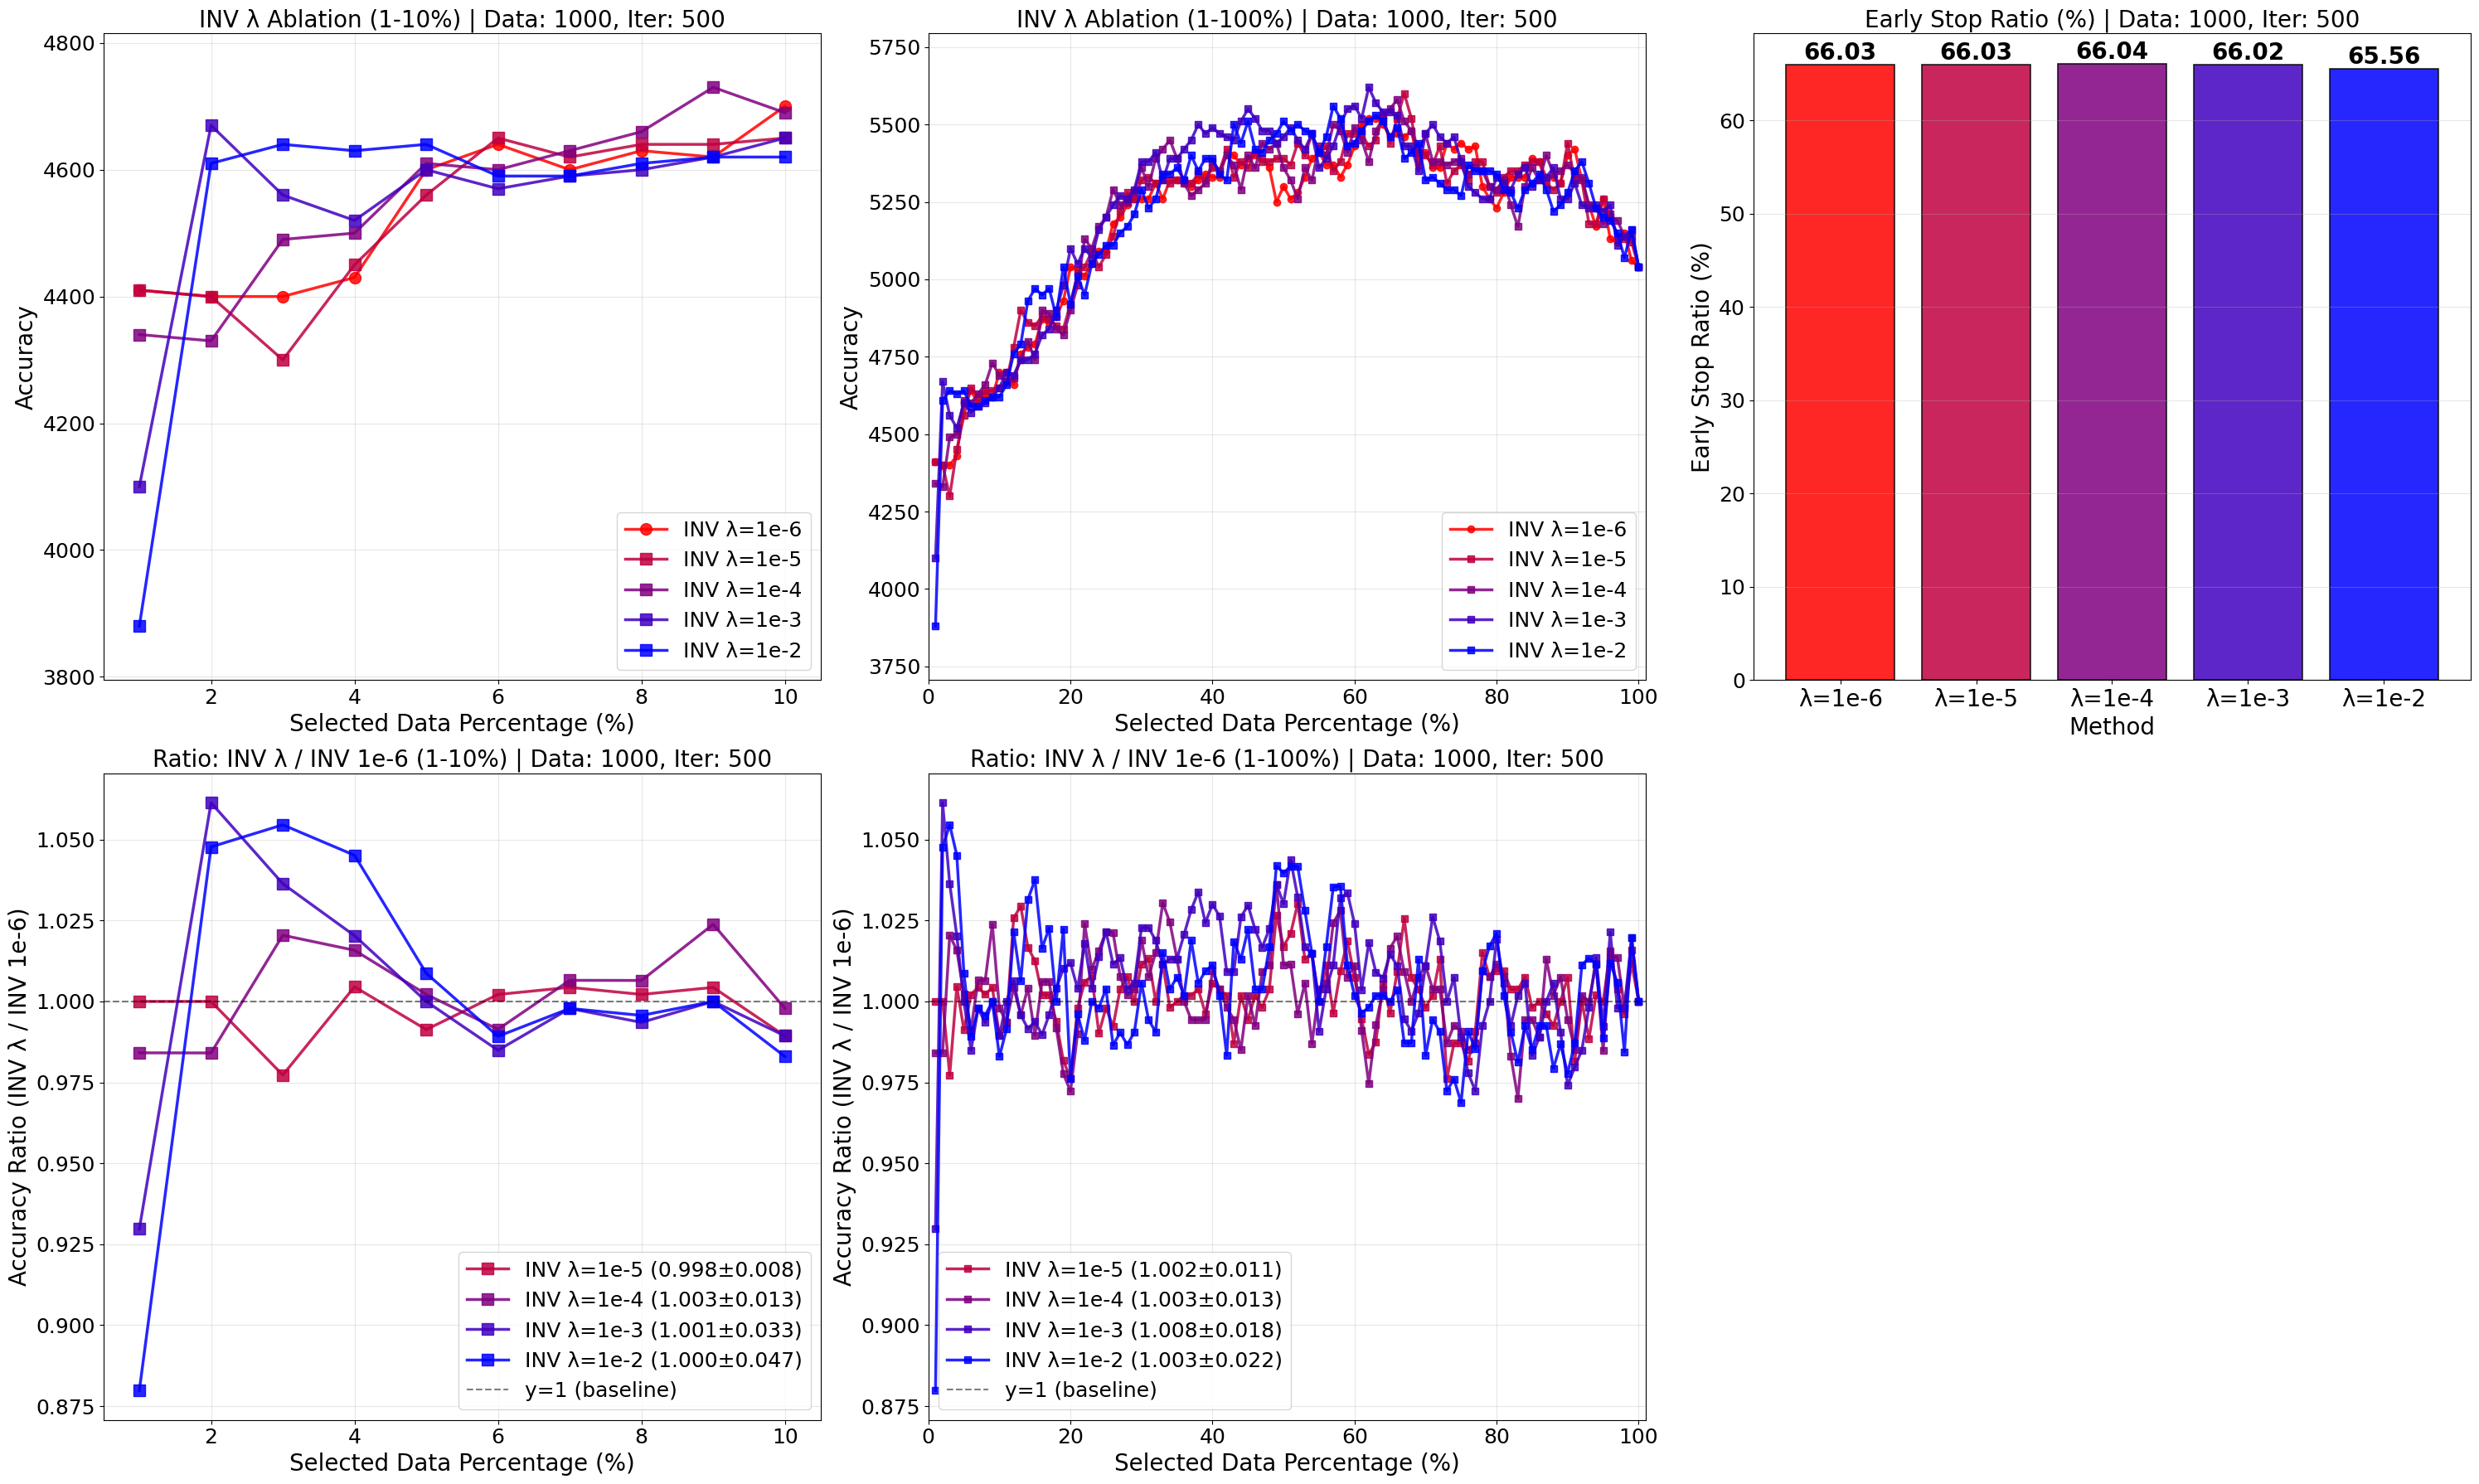

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 1000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [4410, 4400, 4400, 4430, 4600, 4640, 4600, 4630, 4620, 4700, 4700, 4660, 4760, 4780, 4790, 4870, 4860, 4880, 4930, 5040, 5030, 5010, 5050, 5090, 5090, 5180, 5200, 5240, 5260, 5260, 5260, 5310, 5260, 5320, 5320, 5310, 5300, 5320, 5340, 5330, 5330, 5410, 5400, 5370, 5390, 5400, 5390, 5360, 5250, 5300, 5260, 5280, 5330, 5390, 5410, 5370, 5370, 5330, 5370, 5430, 5500, 5520, 5520, 5500, 5460, 5470, 5460, 5480, 5370, 5410, 5360, 5360, 5440, 5420, 5440, 5420, 5430, 5300, 5260, 5230, 5280, 5330, 5330, 5330, 5390, 5380, 5330, 5330, 5310, 5400, 5420, 5320, 5240, 5170, 5260, 5130, 5120, 5150, 5060, 5040]
lam1e_5  = [4410, 4400, 4300, 4450, 4560, 4650, 4620, 4640, 4640, 4650, 4670, 4780, 4900, 4860, 4850, 4880, 4870, 4850, 4840, 4920, 5020, 5040, 5090, 5040, 5080, 5140, 5220, 5280, 5260, 5320, 5330, 5310, 5320, 5310, 5320, 5320, 5310, 5340, 5320, 5360, 5350, 5420, 5330, 5380, 5360, 5410, 5380, 5380, 5390, 5390, 5370, 5440, 5400, 5470, 5410, 5430, 5350, 5380, 5470, 5470, 5470, 5430, 5450, 5530, 5440, 5520, 5600, 5520, 5390, 5400, 5370, 5430, 5310, 5350, 5370, 5320, 5380, 5380, 5300, 5280, 5330, 5350, 5350, 5370, 5380, 5380, 5310, 5290, 5310, 5440, 5320, 5320, 5180, 5180, 5260, 5210, 5140, 5130, 5120, 5040]
lam1e_4  = [4340, 4330, 4490, 4500, 4610, 4600, 4630, 4660, 4730, 4690, 4670, 4680, 4740, 4800, 4740, 4900, 4890, 4840, 4820, 4900, 4980, 5130, 5100, 5170, 5200, 5290, 5240, 5250, 5280, 5360, 5300, 5390, 5420, 5450, 5390, 5310, 5270, 5290, 5310, 5380, 5350, 5400, 5370, 5290, 5400, 5360, 5440, 5420, 5440, 5360, 5320, 5260, 5360, 5320, 5430, 5400, 5500, 5480, 5410, 5490, 5450, 5380, 5480, 5520, 5550, 5580, 5510, 5480, 5410, 5470, 5380, 5380, 5370, 5380, 5390, 5340, 5360, 5350, 5300, 5290, 5320, 5240, 5170, 5300, 5360, 5320, 5400, 5340, 5350, 5370, 5340, 5330, 5240, 5230, 5180, 5200, 5190, 5140, 5140, 5040]
lam1e_3  = [4100, 4670, 4560, 4520, 4600, 4570, 4590, 4600, 4620, 4650, 4700, 4690, 4740, 4740, 4760, 4820, 4840, 4900, 4980, 5100, 5050, 5100, 5070, 5160, 5200, 5240, 5270, 5260, 5290, 5380, 5380, 5410, 5320, 5390, 5390, 5420, 5450, 5500, 5470, 5490, 5470, 5460, 5450, 5510, 5550, 5520, 5480, 5480, 5440, 5460, 5490, 5450, 5420, 5470, 5360, 5390, 5430, 5500, 5550, 5560, 5520, 5620, 5570, 5540, 5540, 5530, 5430, 5430, 5350, 5470, 5500, 5460, 5440, 5460, 5380, 5300, 5280, 5260, 5260, 5330, 5310, 5290, 5340, 5360, 5300, 5320, 5330, 5360, 5260, 5260, 5310, 5240, 5230, 5240, 5220, 5240, 5110, 5140, 5160, 5040]
lam1e_2  = [3880, 4610, 4640, 4630, 4640, 4590, 4590, 4610, 4620, 4620, 4660, 4760, 4790, 4930, 4970, 4950, 4970, 4880, 5040, 4920, 5010, 4950, 5050, 5080, 5110, 5110, 5150, 5170, 5210, 5290, 5230, 5260, 5340, 5340, 5360, 5320, 5400, 5350, 5390, 5390, 5340, 5320, 5500, 5440, 5510, 5420, 5410, 5450, 5470, 5510, 5480, 5500, 5480, 5470, 5410, 5460, 5560, 5520, 5430, 5440, 5480, 5510, 5530, 5510, 5460, 5490, 5390, 5410, 5440, 5320, 5330, 5310, 5290, 5290, 5270, 5370, 5350, 5350, 5350, 5340, 5290, 5280, 5230, 5290, 5310, 5340, 5290, 5220, 5240, 5280, 5350, 5380, 5310, 5230, 5200, 5190, 5150, 5070, 5160, 5040]

lam1e_6_early_stop = [66.03]
lam1e_5_early_stop = [66.03]
lam1e_4_early_stop = [66.04]
lam1e_3_early_stop = [66.02]
lam1e_2_early_stop = [65.56]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

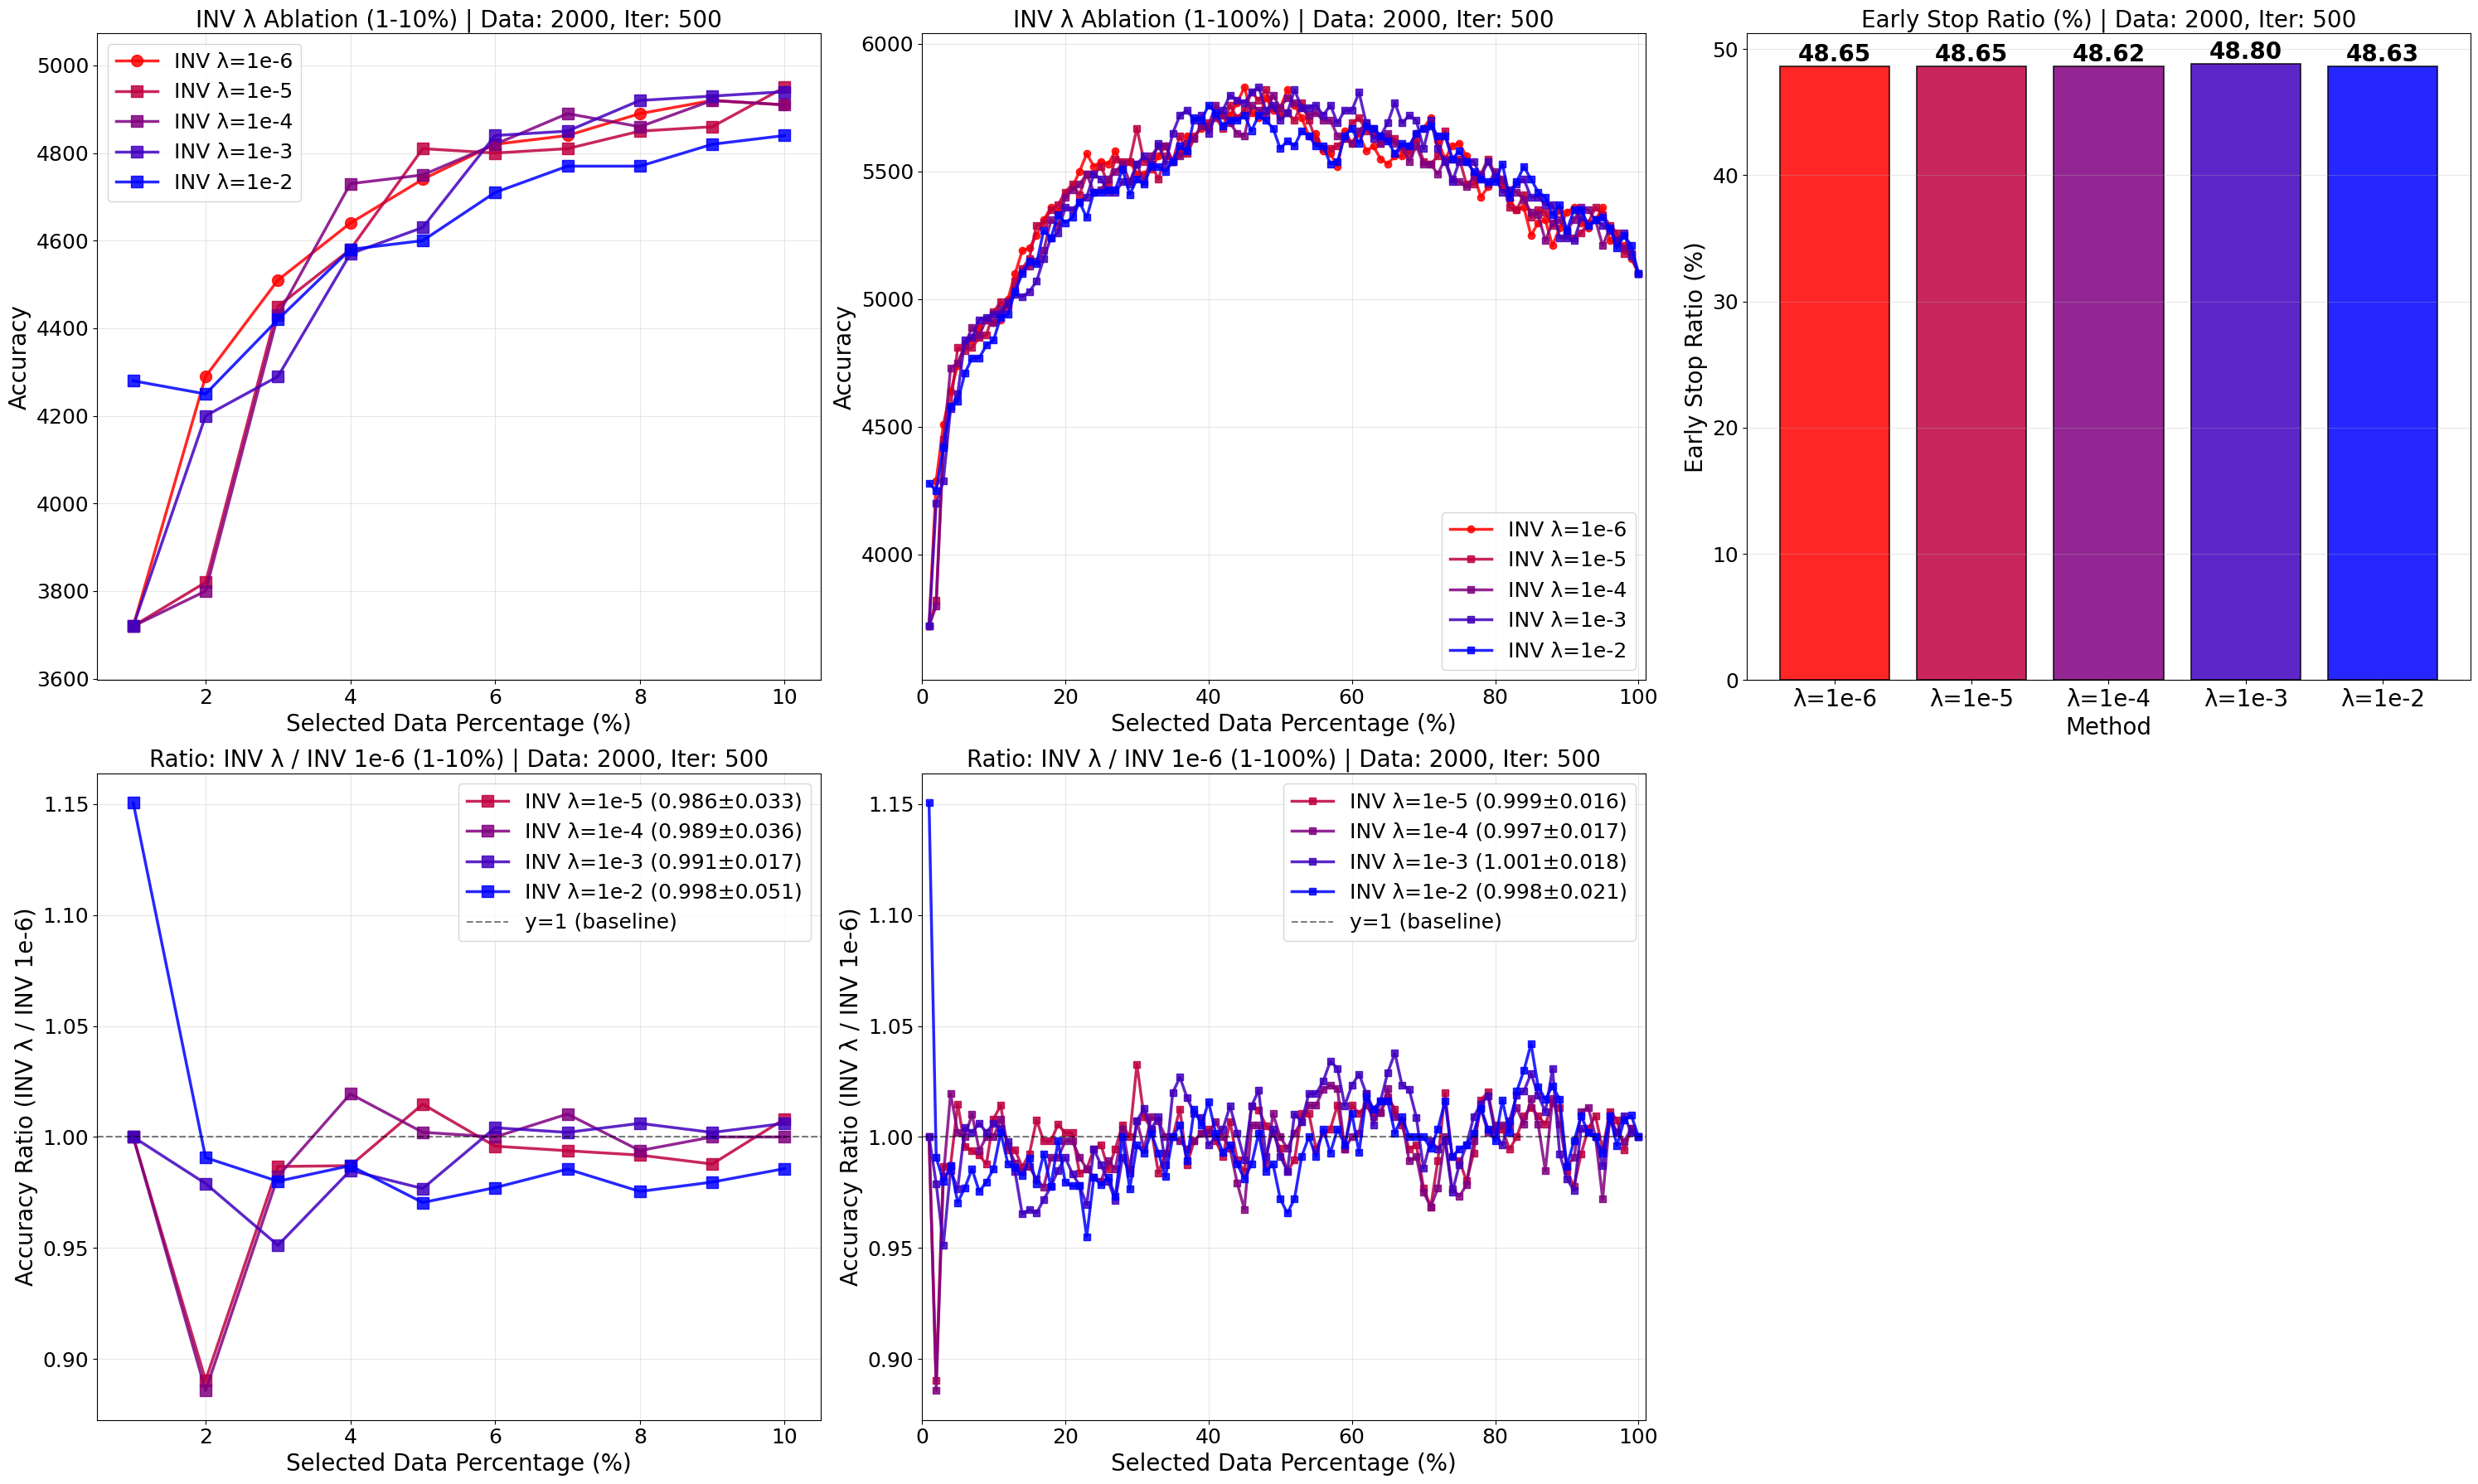

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 2000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [3720, 4290, 4510, 4640, 4740, 4820, 4840, 4890, 4920, 4910, 4920, 5000, 5100, 5190, 5200, 5250, 5310, 5360, 5340, 5410, 5440, 5500, 5570, 5520, 5540, 5530, 5580, 5510, 5540, 5490, 5490, 5510, 5560, 5600, 5540, 5570, 5640, 5640, 5670, 5670, 5720, 5720, 5720, 5770, 5830, 5730, 5710, 5790, 5740, 5750, 5820, 5760, 5710, 5640, 5650, 5580, 5570, 5520, 5660, 5610, 5650, 5580, 5600, 5550, 5530, 5560, 5560, 5600, 5650, 5670, 5710, 5620, 5550, 5600, 5610, 5560, 5490, 5400, 5440, 5470, 5440, 5390, 5350, 5360, 5250, 5300, 5310, 5210, 5280, 5340, 5360, 5300, 5280, 5310, 5360, 5230, 5220, 5210, 5160, 5100]
lam1e_5  = [3720, 3820, 4450, 4580, 4810, 4800, 4810, 4850, 4860, 4950, 4990, 4970, 5070, 5120, 5160, 5290, 5300, 5350, 5370, 5420, 5450, 5410, 5490, 5490, 5520, 5450, 5550, 5540, 5540, 5670, 5540, 5530, 5470, 5560, 5540, 5640, 5570, 5630, 5680, 5690, 5710, 5670, 5760, 5710, 5740, 5810, 5780, 5820, 5750, 5720, 5730, 5700, 5770, 5700, 5620, 5590, 5590, 5600, 5630, 5690, 5710, 5660, 5650, 5610, 5630, 5630, 5590, 5570, 5630, 5540, 5530, 5560, 5660, 5550, 5550, 5450, 5450, 5490, 5550, 5490, 5460, 5360, 5350, 5410, 5320, 5350, 5340, 5290, 5350, 5260, 5240, 5260, 5300, 5360, 5330, 5290, 5260, 5180, 5180, 5100]
lam1e_4  = [3720, 3800, 4430, 4730, 4750, 4820, 4890, 4860, 4920, 4910, 4960, 4980, 5040, 5110, 5130, 5150, 5190, 5310, 5290, 5400, 5430, 5450, 5490, 5420, 5430, 5470, 5500, 5530, 5460, 5530, 5460, 5560, 5600, 5600, 5540, 5560, 5610, 5630, 5680, 5680, 5760, 5720, 5690, 5650, 5640, 5760, 5740, 5720, 5800, 5750, 5790, 5770, 5750, 5720, 5730, 5700, 5700, 5640, 5630, 5610, 5660, 5690, 5670, 5610, 5650, 5610, 5600, 5540, 5600, 5530, 5530, 5490, 5550, 5470, 5460, 5440, 5480, 5470, 5450, 5500, 5470, 5420, 5420, 5390, 5340, 5330, 5230, 5300, 5310, 5270, 5310, 5360, 5350, 5310, 5210, 5280, 5230, 5200, 5180, 5100]
lam1e_3  = [3720, 4200, 4290, 4570, 4630, 4840, 4850, 4920, 4930, 4940, 4940, 4990, 5020, 5010, 5030, 5070, 5160, 5240, 5260, 5360, 5350, 5380, 5400, 5490, 5470, 5420, 5420, 5460, 5450, 5530, 5560, 5530, 5610, 5530, 5650, 5720, 5740, 5700, 5720, 5650, 5720, 5740, 5800, 5780, 5770, 5810, 5830, 5740, 5760, 5700, 5730, 5820, 5750, 5750, 5760, 5720, 5760, 5690, 5740, 5740, 5810, 5690, 5630, 5640, 5690, 5770, 5690, 5720, 5700, 5590, 5700, 5590, 5540, 5460, 5540, 5540, 5540, 5480, 5540, 5480, 5420, 5430, 5450, 5470, 5400, 5400, 5370, 5370, 5240, 5240, 5230, 5320, 5290, 5310, 5290, 5270, 5230, 5260, 5170, 5100]
lam1e_2  = [4280, 4250, 4420, 4580, 4600, 4710, 4770, 4770, 4820, 4840, 4930, 4940, 5030, 5100, 5150, 5140, 5270, 5240, 5330, 5300, 5320, 5380, 5320, 5420, 5420, 5430, 5430, 5510, 5410, 5470, 5450, 5520, 5520, 5500, 5540, 5600, 5580, 5710, 5700, 5760, 5730, 5680, 5700, 5700, 5720, 5660, 5720, 5700, 5670, 5590, 5620, 5600, 5660, 5640, 5600, 5600, 5530, 5540, 5640, 5670, 5610, 5680, 5670, 5640, 5620, 5570, 5610, 5600, 5650, 5670, 5680, 5640, 5640, 5550, 5580, 5540, 5500, 5470, 5460, 5460, 5530, 5400, 5460, 5520, 5470, 5420, 5400, 5330, 5370, 5270, 5350, 5350, 5290, 5310, 5320, 5280, 5200, 5250, 5210, 5100]

lam1e_6_early_stop = [48.65]
lam1e_5_early_stop = [48.65]
lam1e_4_early_stop = [48.62]
lam1e_3_early_stop = [48.80]
lam1e_2_early_stop = [48.63]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

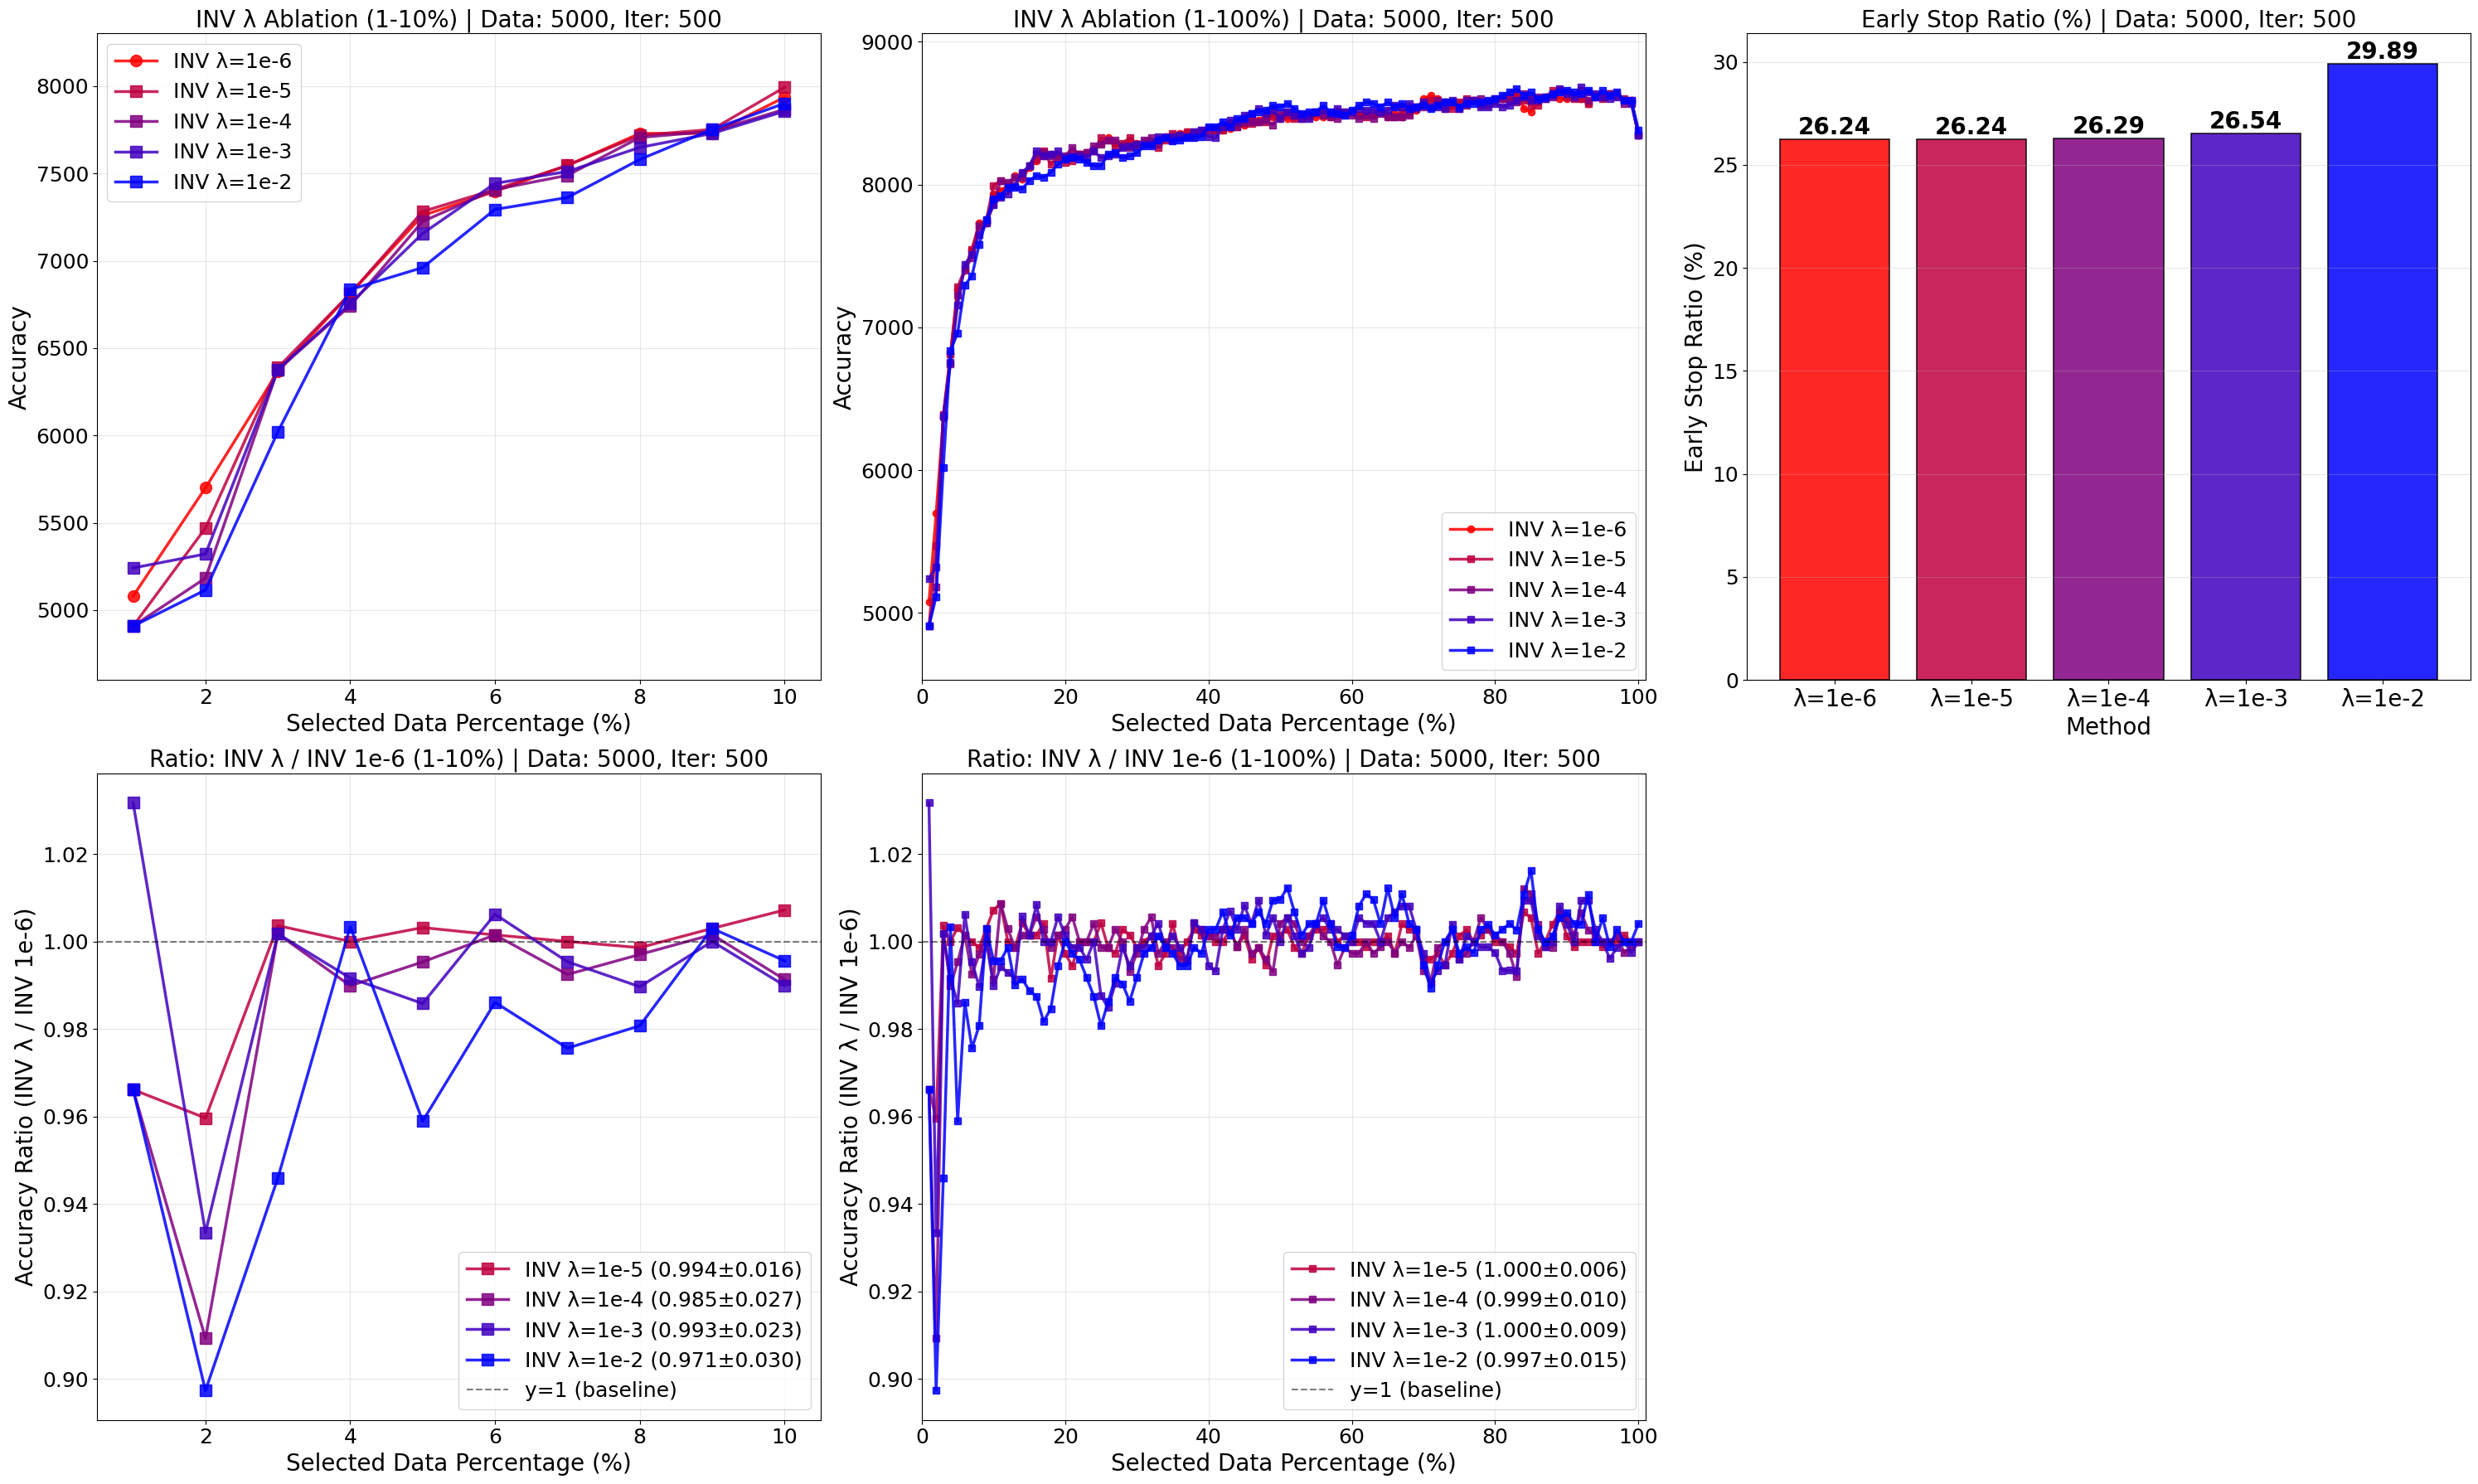

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 5000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 10000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()